In [1]:
import datetime
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.attr001.ftd001 import *

/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:11: UserWarning: if use distributed calculating, please configure MQ_URL
  warnings.warn('if use distributed calculating, please configure MQ_URL')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:15: UserWarning: if use distributed calculating, please configure NTN_URL
  warnings.warn('if use distributed calculating, please configure NTN_URL')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:19: UserWarning: if use memory database, please configure KN_MG
  warnings.warn('if use memory database, please configure KN_MG')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:27: UserWarning: if use trader, please configure ATL_URL
  warnings.warn('if use trader, please configure ATL_URL')
/workspace/worker/env/lingua/lib

In [3]:
mongo_client = MongoDBManager(uri=os.environ['MG_URI'])

In [4]:
begin_time=datetime.datetime(2026,5,1)
end_time=datetime.datetime(2026,5,27)

In [5]:
metrics_data = fetch_netout_metrics(mongo_client=mongo_client,
                                    code='RB',
                                    category=['bench', 'research'],
                                    begin_time=begin_time,
                                    end_time=end_time,
                                    task_id='1029921127239410')

metrics_data = metrics_data[[
    'trade_date', 'category', 'gross_nav', 'net_nav', 'maxdd', 'turnover',
    'profit_ratio', 'ic'
]]

{'code': 'RB', 'task_id': '1029921127239410', 'trade_date': {'$gte': datetime.datetime(2026, 5, 1, 0, 0), '$lte': datetime.datetime(2026, 5, 27, 0, 0)}, 'category': {'$in': ['bench', 'research']}}


In [6]:
metrics_data

,trade_date,category,gross_nav,net_nav,maxdd,turnover,profit_ratio,ic
0,2026-05-07,bench,-0.003721,-0.003964,0.000000,0.350055,0.935492,0.000261
1,2026-05-07,research,-0.007317,-0.007563,0.000000,0.351230,0.874675,0.000959
2,2026-05-08,bench,0.013846,0.013575,0.000000,0.391526,1.212748,0.001233
3,2026-05-08,research,0.011212,0.010968,0.000000,0.349327,1.169027,0.000224
4,2026-05-11,bench,0.007681,0.007449,0.000000,0.336382,1.110526,0.002138
5,2026-05-11,research,0.011109,0.010880,0.000000,0.329043,1.164958,0.001635
6,2026-05-12,bench,0.004732,0.004480,0.000000,0.363938,1.059496,-0.003042
7,2026-05-12,research,-0.002031,-0.002267,-0.002265,0.338771,0.971471,-0.003023
8,2026-05-13,bench,-0.005137,-0.005378,-0.005363,0.348524,0.907035,0.000229
9,2026-05-13,research,-0.003564,-0.003809,-0.006057,0.351162,0.936632,-0.000464


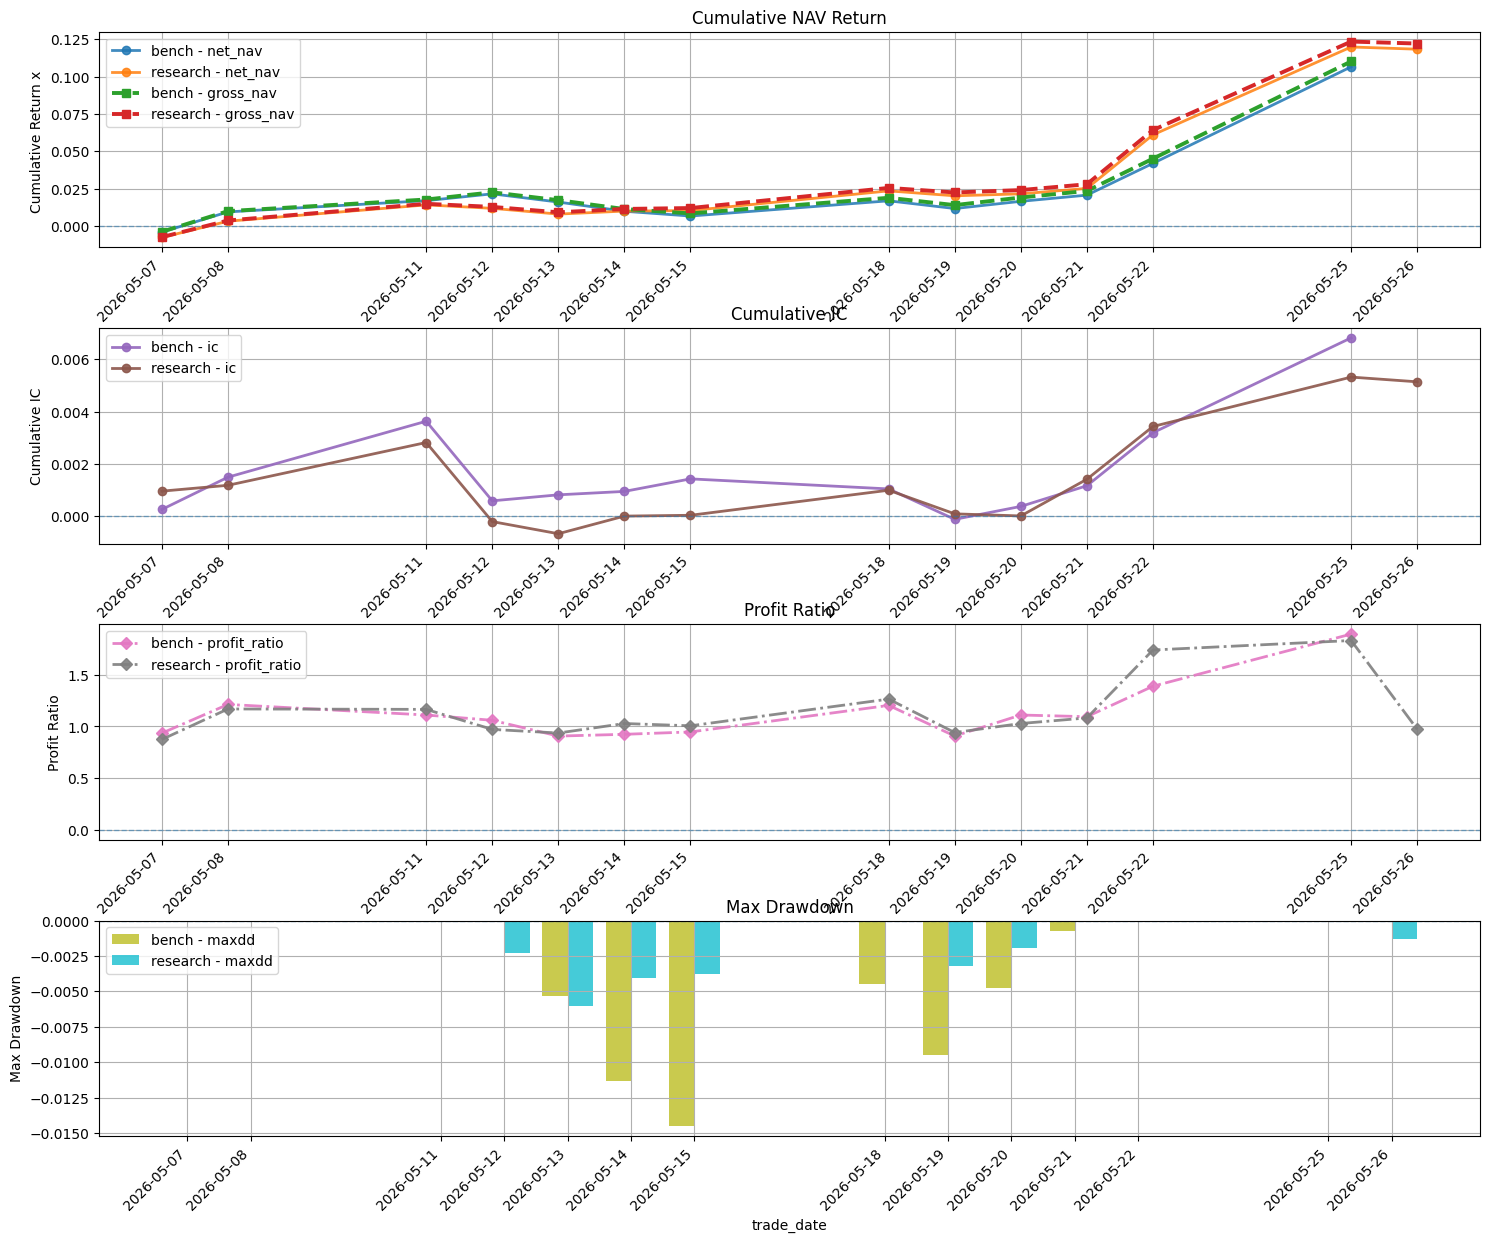

In [7]:
fig, axes = plot_netout(metrics_data, markersize=6)